# Analisis Senyar Cylone

In [12]:
from pathlib import Path
import glob
import os

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# file path proyek yang akan digunakan
path_top = Path("D:/ERA5_REANALYSIS")

In [14]:
# melihat data single layer harian ERA5_Reanalysis
ds = xr.open_dataset(path_top / "ERA5_SingleLevel_DailyMeanandSum_20250101-20260331.nc", engine="netcdf4")
display(ds)

<xarray.Dataset> Size: 217MB
Dimensions:     (valid_time: 455, latitude: 50, longitude: 77)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 400B 10.75 10.5 10.25 ... -1.0 -1.25 -1.5
  * longitude   (longitude) float64 616B 93.0 93.25 93.5 ... 111.5 111.8 112.0
    number      int64 8B ...
Data variables: (12/31)
    u100        (valid_time, latitude, longitude) float32 7MB ...
    v100        (valid_time, latitude, longitude) float32 7MB ...
    u10n        (valid_time, latitude, longitude) float32 7MB ...
    u10         (valid_time, latitude, longitude) float32 7MB ...
    v10n        (valid_time, latitude, longitude) float32 7MB ...
    v10         (valid_time, latitude, longitude) float32 7MB ...
    ...          ...
    tvh         (valid_time, latitude, longitude) float32 7MB ...
    tvl         (valid_time, latitude, longitude) float32 7MB ...
    swvl1       (valid_time, latitude, longitude) float32 7MB ...
    swvl2       (valid_time, latitude, longitude) float32 7MB ...
    swvl3       (valid_time, latitude, longitude) float32 7MB ...
    swvl4       (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-14T14:15 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
# menghitung relative humidity dari temperatur udara dan temperatur titik embun
def calculate_rh(temperature, dewpoint):
    """
    Calculate relative humidity from temperature and dewpoint.
    
    Parameters:
    temperature (float or array-like): Temperature in degrees Kelvin.
    dewpoint (float or array-like): Dewpoint temperature in degrees Kelvin.
    
    Returns:
    float or array-like: Relative humidity in percentage.
    """
    # Convert temperatures to Celsius
    temp_c = temperature - 273.15
    dewpoint_c = dewpoint - 273.15
    
    # Calculate saturation vapor pressure (in hPa)
    es = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    
    # Calculate actual vapor pressure (in hPa)
    e = 6.112 * np.exp((17.67 * dewpoint_c) / (dewpoint_c + 243.5))
    
    # Calculate relative humidity
    rh = (e / es) * 100
    
    return rh

In [16]:
# membuat data variabel baru untuk relative humidity
ds['rh'] = xr.apply_ufunc(calculate_rh, ds['t2m'], ds['d2m'], vectorize=True)
ds['rh'].attrs['units'] = '%'
ds['rh'].attrs['long_name'] = '2m Relative Humidity'
display(ds)

<xarray.Dataset> Size: 224MB
Dimensions:     (valid_time: 455, latitude: 50, longitude: 77)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 400B 10.75 10.5 10.25 ... -1.0 -1.25 -1.5
  * longitude   (longitude) float64 616B 93.0 93.25 93.5 ... 111.5 111.8 112.0
    number      int64 8B 0
Data variables: (12/32)
    u100        (valid_time, latitude, longitude) float32 7MB ...
    v100        (valid_time, latitude, longitude) float32 7MB ...
    u10n        (valid_time, latitude, longitude) float32 7MB ...
    u10         (valid_time, latitude, longitude) float32 7MB ...
    v10n        (valid_time, latitude, longitude) float32 7MB ...
    v10         (valid_time, latitude, longitude) float32 7MB ...
    ...          ...
    tvl         (valid_time, latitude, longitude) float32 7MB ...
    swvl1       (valid_time, latitude, longitude) float32 7MB ...
    swvl2       (valid_time, latitude, longitude) float32 7MB ...
    swvl3       (valid_time, latitude, longitude) float32 7MB ...
    swvl4       (valid_time, latitude, longitude) float32 7MB ...
    rh          (valid_time, latitude, longitude) float32 7MB 80.63 ... 87.66
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-14T14:15 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
# membuat nama variabel yang ada di dataset
ds_keys = ds._variables.keys()
var_names = [var for var in ds_keys if var not in ['latitude', 'longitude', 'valid_time','number']]
var_long_names = [ds[var].long_name for var in var_names]
var_name = dict(zip(var_names, var_long_names))
var_name

{'u100': '100 metre U wind component',
 'v100': '100 metre V wind component',
 'u10n': '10 metre u-component of neutral wind',
 'u10': '10 metre U wind component',
 'v10n': '10 metre v-component of neutral wind',
 'v10': '10 metre V wind component',
 'd2m': '2 metre dewpoint temperature',
 't2m': '2 metre temperature',
 'cp': 'Convective precipitation',
 'crr': 'Convective rain rate',
 'cvh': 'High vegetation cover',
 'lsp': 'Large-scale precipitation',
 'lspf': 'Large-scale precipitation fraction',
 'lsrr': 'Large scale rain rate',
 'cvl': 'Low vegetation cover',
 'msl': 'Mean sea level pressure',
 'ro': 'Runoff',
 'sst': 'Sea surface temperature',
 'skt': 'Skin temperature',
 'sp': 'Surface pressure',
 'sro': 'Surface runoff',
 'tcc': 'Total cloud cover',
 'tclw': 'Total column cloud liquid water',
 'tcrw': 'Total column rain water',
 'tp': 'Total precipitation',
 'tvh': 'Type of high vegetation',
 'tvl': 'Type of low vegetation',
 'swvl1': 'Volumetric soil water layer 1',
 'swvl2': 

### Contoh : Kota Medan

In [17]:
# get the latitude and longitude bounds for Medan city
lat_min, lat_max = 3.3833, 3.7500  # Approximate latitude bounds for Medan
lon_min, lon_max = 98.3333, 98.7500  # Approximate longitude bounds for Medan

# Select data within the specified bounds
ds_medan = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# Display the selected dataset
print("Dataset for Medan:")
display(ds_medan)

# Calculate the number of grid points
num_grids = len(ds_medan.latitude) * len(ds_medan.longitude)
print(f"Number of grids used: {num_grids}")

# Convert to DataFrame
df_medan = ds_medan.to_dataframe().reset_index()
print("\nDataFrame for Medan:")
display(df_medan)

Dataset for Medan:


<xarray.Dataset> Size: 237kB
Dimensions:     (valid_time: 455, latitude: 2, longitude: 2)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 16B 3.75 3.5
  * longitude   (longitude) float64 16B 98.5 98.75
    number      int64 8B 0
Data variables: (12/32)
    u100        (valid_time, latitude, longitude) float32 7kB ...
    v100        (valid_time, latitude, longitude) float32 7kB ...
    u10n        (valid_time, latitude, longitude) float32 7kB ...
    u10         (valid_time, latitude, longitude) float32 7kB ...
    v10n        (valid_time, latitude, longitude) float32 7kB ...
    v10         (valid_time, latitude, longitude) float32 7kB ...
    ...          ...
    tvl         (valid_time, latitude, longitude) float32 7kB ...
    swvl1       (valid_time, latitude, longitude) float32 7kB ...
    swvl2       (valid_time, latitude, longitude) float32 7kB ...
    swvl3       (valid_time, latitude, longitude) float32 7kB ...
    swvl4       (valid_time, latitude, longitude) float32 7kB ...
    rh          (valid_time, latitude, longitude) float32 7kB 83.76 ... 83.76
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-14T14:15 GRIB to CDM+CF via cfgrib-0.9.1...

Number of grids used: 4

DataFrame for Medan:


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number,rh
0,2025-01-01,3.75,98.50,1.068951,-0.314060,0.504612,0.577389,-0.230350,-0.077847,297.607483,...,0.001495,0.000590,6.0,1.0,0.408256,0.413693,0.418091,0.424625,0,83.760651
1,2025-01-01,3.75,98.75,1.730816,-0.766453,0.812229,0.852047,-0.704227,-0.503872,297.966370,...,0.002228,0.000862,6.0,1.0,0.424888,0.431805,0.423523,0.443874,0,85.251587
2,2025-01-01,3.50,98.50,1.020611,-0.483494,0.470921,0.524899,0.215694,0.311314,296.206116,...,0.002350,0.001467,6.0,1.0,0.398418,0.403366,0.420986,0.429108,0,83.238625
3,2025-01-01,3.50,98.75,2.098248,-0.485935,0.953098,0.996822,-0.044315,0.106236,296.645569,...,0.000885,0.003532,6.0,1.0,0.424282,0.430962,0.412083,0.449337,0,81.606926
4,2025-01-02,3.75,98.50,1.815887,-1.117908,0.930264,0.984680,-0.691376,-0.609913,297.935181,...,0.004547,0.003859,6.0,1.0,0.398987,0.401205,0.414145,0.424240,0,83.730934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,2026-03-30,3.50,98.75,-0.833660,1.140862,NaN,NaN,0.922356,0.921997,297.612183,...,0.001129,0.008347,6.0,1.0,0.352856,0.284421,0.274073,0.398453,0,85.542145
1816,2026-03-31,3.75,98.50,-0.774933,-0.165180,NaN,NaN,0.136150,0.074902,297.847412,...,0.006195,0.005151,6.0,1.0,0.319237,0.285139,0.284910,0.367722,0,86.084648
1817,2026-03-31,3.75,98.75,-1.088898,0.341412,NaN,NaN,0.419598,0.381298,297.821045,...,0.001282,0.005711,6.0,1.0,0.394364,0.338659,0.346708,0.402294,0,85.634270
1818,2026-03-31,3.50,98.50,-0.800079,0.250591,NaN,NaN,0.500652,0.414013,296.146729,...,0.010803,0.006601,6.0,1.0,0.396851,0.361761,0.280874,0.376953,0,85.644081


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number,rh
0,2025-01-01,3.625,98.625,1.479656,-0.512486,0.685215,0.737789,-0.190800,-0.041042,297.106384,...,0.001740,0.001613,6.0,1.0,0.413961,0.419957,0.418671,0.436736,0.0,83.464447
1,2025-01-02,3.625,98.625,2.084991,-1.309742,0.980251,1.058228,-0.718475,-0.624744,297.731445,...,0.011848,0.005488,6.0,1.0,0.407866,0.409235,0.414590,0.436193,0.0,84.573746
2,2025-01-03,3.625,98.625,3.023396,-0.478245,1.575836,1.604748,-0.006859,0.067612,297.661194,...,0.018585,0.005667,6.0,1.0,0.418203,0.414524,0.411155,0.435646,0.0,88.275406
3,2025-01-04,3.625,98.625,0.738224,-0.343590,0.023254,0.137348,-0.101223,0.040268,297.536987,...,0.005020,0.009420,6.0,1.0,0.414211,0.416540,0.408321,0.435102,0.0,87.973549
4,2025-01-05,3.625,98.625,-0.880718,0.061317,-0.357937,-0.319496,0.227398,0.252544,297.764282,...,0.014137,0.018980,6.0,1.0,0.421096,0.423751,0.407620,0.434515,0.0,89.244476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,3.625,98.625,1.670738,-0.399265,NaN,NaN,-0.100006,-0.001007,296.783997,...,0.000168,0.000164,6.0,1.0,0.259181,0.294474,0.302102,0.387923,0.0,77.810135
451,2026-03-28,3.625,98.625,0.947590,0.327297,NaN,NaN,0.226406,0.318268,297.453857,...,0.003380,0.007165,6.0,1.0,0.289485,0.288340,0.300638,0.387500,0.0,86.171700
452,2026-03-29,3.625,98.625,-0.821697,0.724987,NaN,NaN,0.605732,0.568947,297.527771,...,0.005463,0.007957,6.0,1.0,0.345517,0.293268,0.298939,0.387089,0.0,86.611061
453,2026-03-30,3.625,98.625,-0.827984,0.628166,NaN,NaN,0.648552,0.580505,297.825195,...,0.002060,0.009893,6.0,1.0,0.347716,0.302342,0.296844,0.386654,0.0,85.730522


,valid_time,tp,lsp,sp,t2m,rh
0,2025-01-01,1.612902,0.432014,1003.847046,26.996857,83.464447
1,2025-01-02,5.488157,1.732349,1003.490784,27.410126,84.573746
2,2025-01-03,5.666614,0.902295,1004.040466,26.611359,88.275406
3,2025-01-04,9.419680,0.544190,1003.803284,26.545380,87.973549
4,2025-01-05,18.979549,0.891089,1004.053894,26.529633,89.244476
...,...,...,...,...,...,...
450,2026-03-27,0.163913,0.031829,1002.281433,27.864349,77.810135
451,2026-03-28,7.164717,0.999093,1001.943726,26.809967,86.171700
452,2026-03-29,7.957101,2.534747,1002.524231,26.802032,86.611061
453,2026-03-30,9.893060,0.139356,1003.029236,27.277069,85.730522


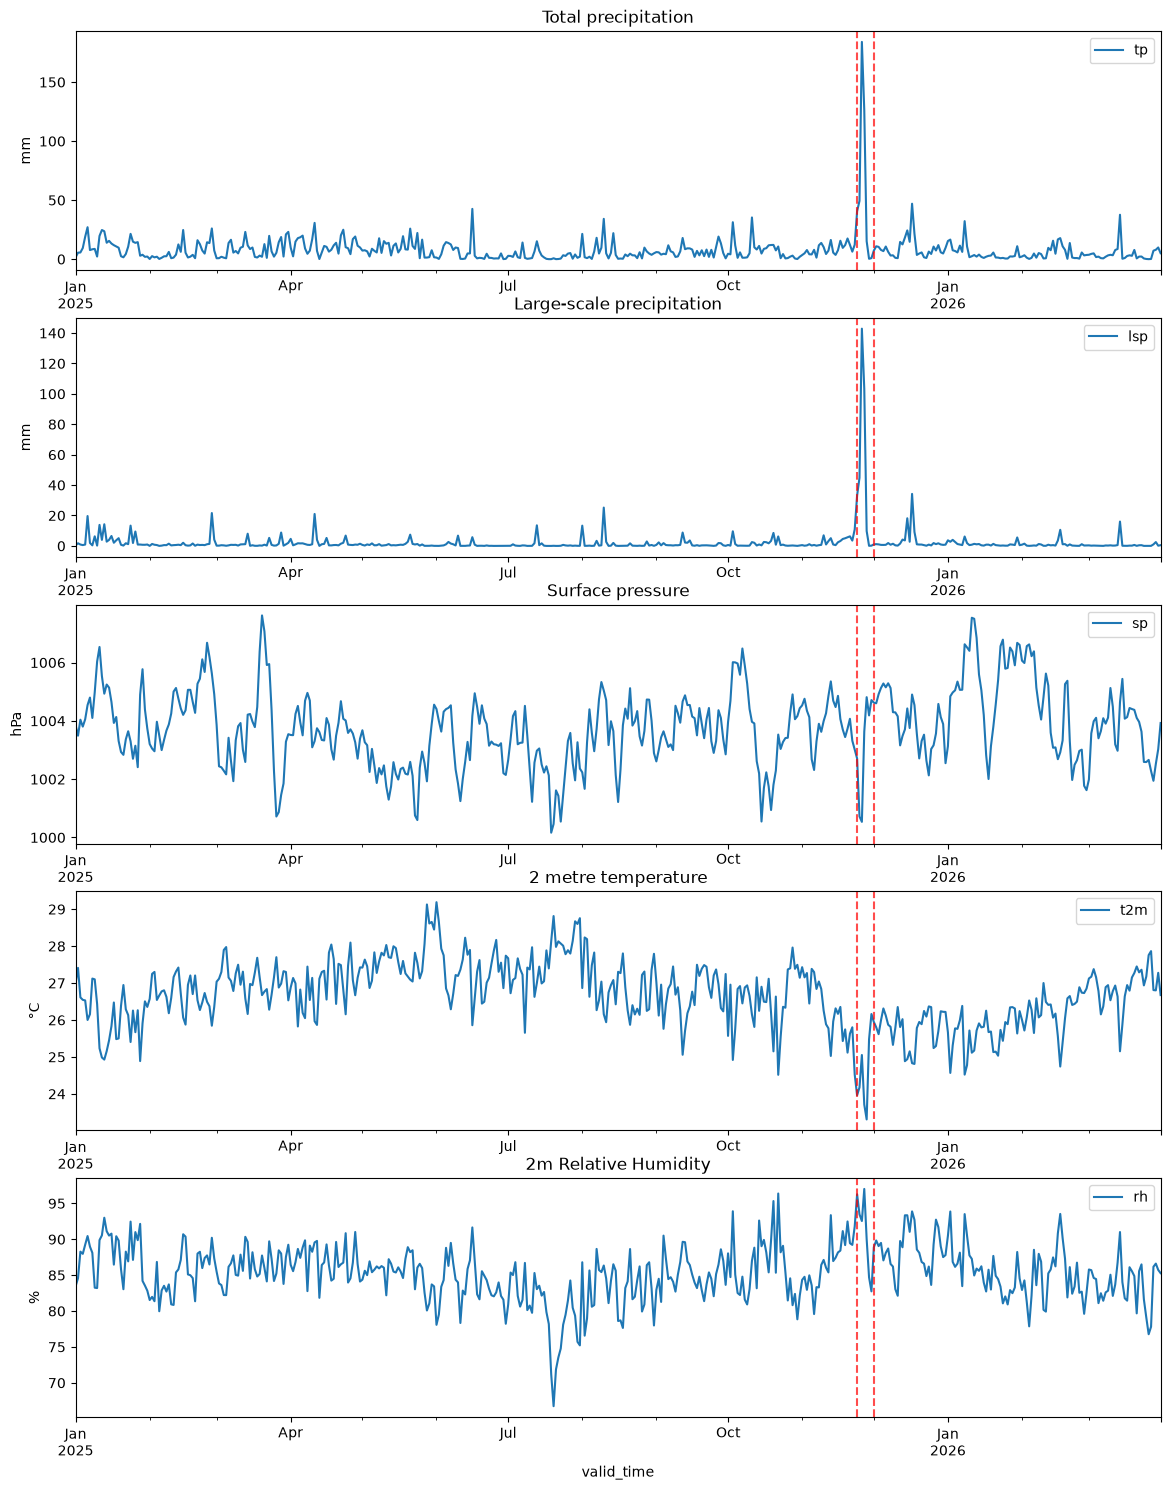

In [9]:
# Calculate the mean for each valid_time
df_medan_mean_time = df_medan.groupby('valid_time').mean().reset_index()
display(df_medan_mean_time)

# Plotting daily total precipitation in Medan
daily_tp = df_medan_mean_time[['valid_time', 'tp','lsp','sp','t2m','rh']].copy()
daily_tp[['tp','lsp']] = daily_tp[['tp','lsp']] * 1000  # Convert from meters to millimeters
daily_tp['sp'] = daily_tp['sp'] / 100  # Convert from Pa to hPa
daily_tp['t2m'] = daily_tp['t2m'] - 273.15
display(daily_tp)

# Plot with subplots
units_var = {'tp': 'mm', 'lsp': 'mm', 'sp': 'hPa', 't2m': '°C', 'rh': '%'}
fig, axes = plt.subplots(5, 1, figsize=(14,18))
for i, col in enumerate (['tp','lsp','sp','t2m','rh']):
    daily_tp.plot(kind='line', x='valid_time', y=col, 
                  title=f'{var_name[col]}', ax=axes[i])
    axes[i].set_ylabel(f'{units_var[col]}')

# Add vertical lines to each subplot
for ax in axes:
    ax.axvline(x=pd.Timestamp('2025-11-24'), color='red', linestyle='--', alpha=0.7)
    ax.axvline(x=pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)

In [10]:
# Visualisasi yang sama seperti di atas, tetapi menggunakan Plotly (interaktif)
import plotly.graph_objects as go
from plotly.subplots import make_subplots

cols = ['tp', 'lsp', 'sp', 't2m', 'rh']

fig_plotly = make_subplots(
    rows=5, cols=1,
    shared_xaxes=True,
    subplot_titles=[var_name[col] for col in cols],
    vertical_spacing=0.06
)

# Tambahkan line trace untuk setiap variabel
for i, col in enumerate(cols, start=1):
    fig_plotly.add_trace(
        go.Scatter(
            x=daily_tp['valid_time'],
            y=daily_tp[col],
            mode='lines',
            name=f'{col} ({units_var[col]})'
        ),
        row=i, col=1
    )
    fig_plotly.update_yaxes(title_text=units_var[col], row=i, col=1)

# Tambahkan garis vertikal penanda di setiap subplot
for i in range(1, 6):
    fig_plotly.add_vline(x=pd.Timestamp('2025-11-24'), line_color='red',
                         line_dash='dash', opacity=0.7, row=i, col=1)
    fig_plotly.add_vline(x=pd.Timestamp('2025-12-01'), line_color='red',
                         line_dash='dash', opacity=0.7, row=i, col=1)

fig_plotly.update_layout(
    height=1200,
    title_text='Time Series Variabel Meteorologi di Kota Medan (Plotly)',
    showlegend=False,
    hovermode='x unified'
)
fig_plotly.update_xaxes(title_text='Valid Time', row=5, col=1)

fig_plotly.show()

Tabel berikut merinci kepanjangan dari singkatan nama variabel pada dataset `ds` beserta satuannya, diformat menggunakan LaTeX untuk keperluan ilmiah:

Daftar Variabel Dataset ERA5 beserta Kepanjangan dan Satuannya
1. u10      : 10 metre U wind component $(m/s)$ 
2. v10      : 10 metre V wind component $(m/s)$ 
3. u100     : 100 metre U wind component $(m/s)$ 
4. v100     : 100 metre V wind component $(m/s)$
5. u10n     : 10 metre U wind component (neutral) $(m/s)$ 
6. v10n     : 10 metre V wind component (neutral) $(m/s)$ 
7. t2m      : 2 metre temperature $(Kelvin)$
8. d2m      : 2 metre dewpoint temperature $(Kelvin)$
9. cp       : Convective precipitation $(meter)$
10. crr      : Convective rain rate $(kg/m^{2}.s)$
11. cvh      : Convective precipitation rate $(kg/m^{2}.s)$
12. lsp     : Large scale precipitation $(meter)$
13. lspf    : Large scale precipitation rate $(kg/m^{2}.s)$
14. lsrr    : Large scale rain rate $(kg/m^{2}.s)$
15. cvl     : Convective snow rate $(kg/m^{2}.s)$
16. msl     : Mean sea level pressure $(Pascal)$
17. ro      : Runoff $(meter)$
18. sst     : Sea surface temperature $(Kelvin)$
19. skt     : Skin temperature $(Kelvin)$
20. sp      : Surface pressure $(Pascal)$
21. sro     : Surface runoff $(meter)$
22. tcc     : Total cloud cover (0 - 1)
23. tclw    : Total column liquid water $(kg/m^{2})$
24. tcrw    : Total column rain water $(kg/m^{2})$
25. tp      : Total precipitation $(meter)$
26. tvh     : Total column vertically integrated heat/moisture -
27. tvl     : Total column vertically integrated liquid -
28. swvl1   : Soil water level 1 $(m^3.m^{-3})$
29. swvl2   : Soil water level 2 $(m^3.m^{-3})$
30. swvl3   : Soil water level 3 $(m^3.m^{-3})$
31. swvl4   : Soil water level 4 $(m^3.m^{-3})$

In [18]:
# merubah satuan dari data ERA5
ds_copy = ds.copy()
# untuk total precipitation (tp) dan large scale precipitation (lsp) dari meter ke millimeter
ds_copy[['tp','lsp']] = ds_copy[['tp','lsp']] * 1000  # Convert from meters to millimeters
# untuk surface pressure (sp) dan mean sea level pressure (msl) dari hPa ke Pa
ds_copy[['sp','msl']] = ds_copy[['sp','msl']] * 100  # Convert from hPa to Pa


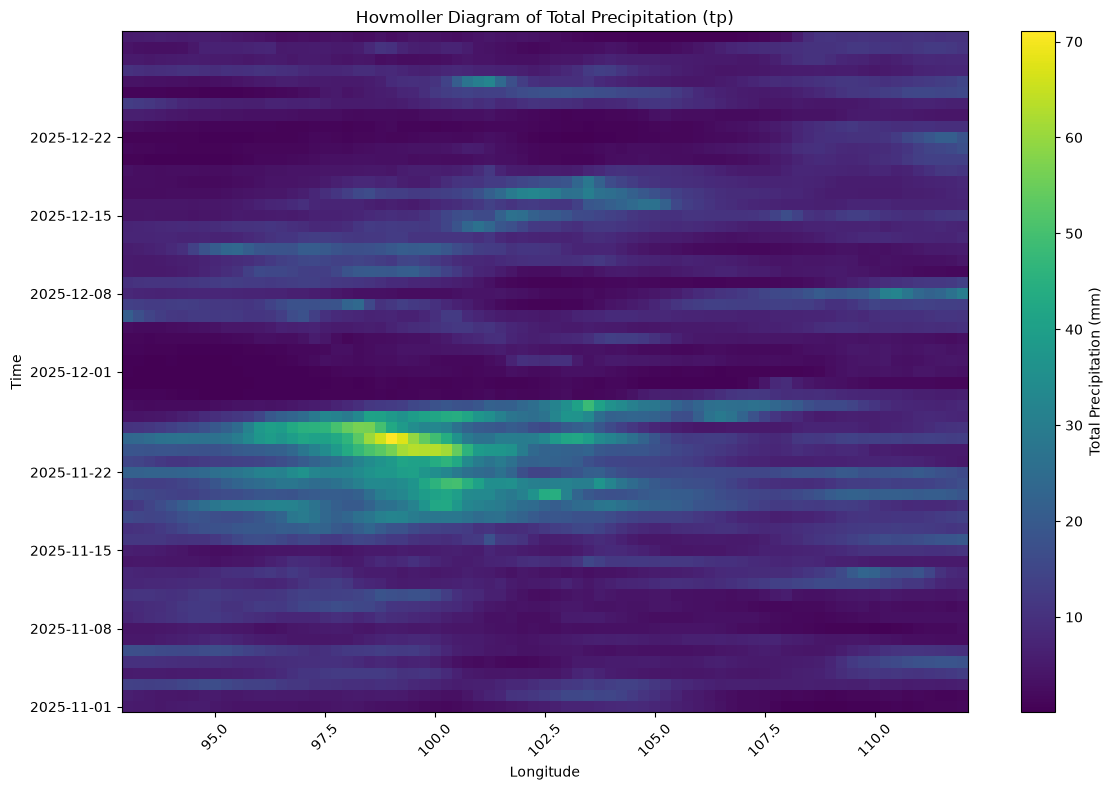

In [17]:
# Create Hovmoller diagram with longitude on x-axis and time on y-axis for variable tp
fig, ax = plt.subplots(figsize=(12, 8))

# filter waktu valid_time between 2025-11-01 and 2025-12-31
ds_filtered = ds_copy.sel(valid_time=slice('2025-11-01', '2025-12-31'))

# Plot the Hovmoller diagram
im = ax.pcolormesh(ds_filtered.longitude, ds_filtered.valid_time, ds_filtered.tp.mean(dim='latitude'), cmap='viridis', shading='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Precipitation (mm)')

# Set labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Time')
ax.set_title('Hovmoller Diagram of Total Precipitation (tp)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

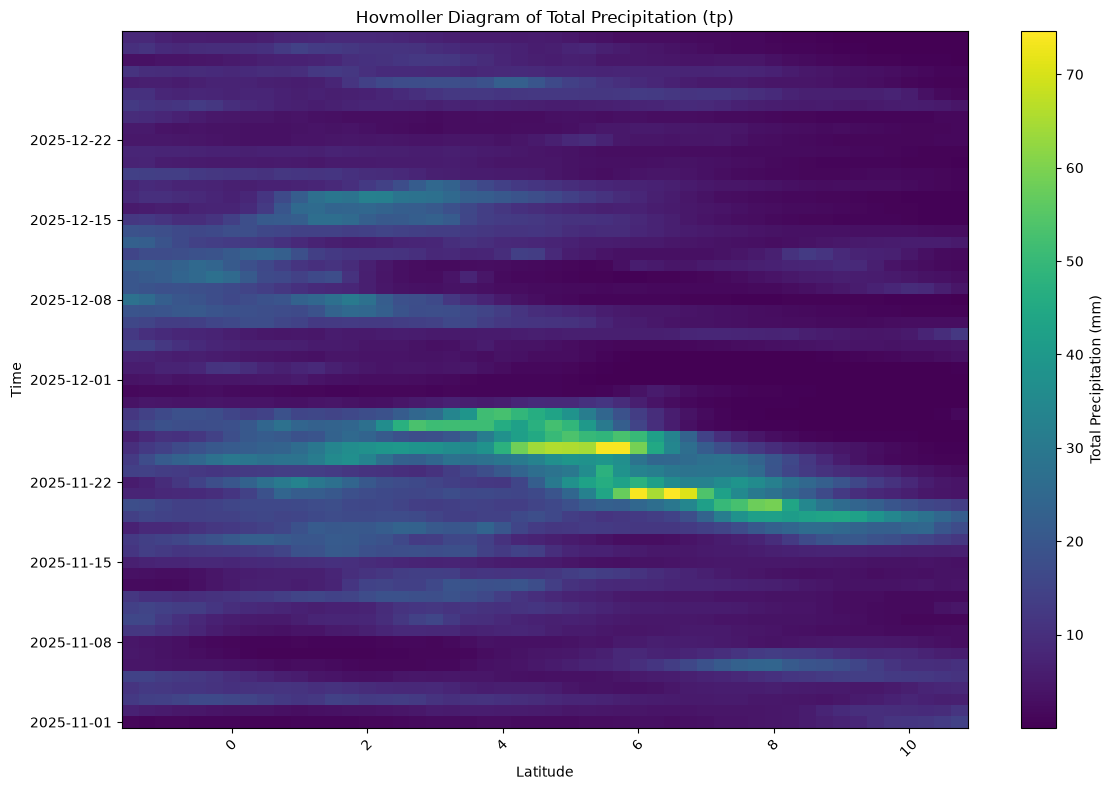

In [35]:
# Create Hovmoller diagram with longitude on x-axis and time on y-axis for variable tp
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Hovmoller diagram
im = ax.pcolormesh(ds_filtered.latitude, ds_filtered.valid_time, ds_filtered.tp.mean(dim='longitude'), cmap='viridis', shading='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Precipitation (mm)')

# Set labels and title
ax.set_xlabel('Latitude')
ax.set_ylabel('Time')
ax.set_title('Hovmoller Diagram of Total Precipitation (tp)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

## Analisis Lag Correlation: Total Precipitation (tp)

Lag correlation menghitung korelasi Pearson antara deret waktu `tp` pada setiap bujur (rata-rata terhadap latitude) dengan suatu deret waktu referensi untuk berbagai pergeseran waktu (lag). Hasil divisualisasikan sebagai peta 2D dengan **sumbu x = longitude**, **sumbu y = lag waktu (hari)**, dan warna = nilai korelasi.

- **Referensi**: `tp` rata-rata pada kotak wilayah Kota Medan (didefinisikan pada cell sebelumnya).
- **Konvensi lag**: `corr(lag)` = korelasi antara $ref(t)$ dengan $tp(t + lag)$. Lag positif berarti curah hujan di longitude tersebut berpuncak *setelah* Medan; lag negatif berarti *sebelum* Medan (berguna untuk melihat arah perambatan sistem hujan).
- Sebelum korelasi dihitung, siklus musiman dihilangkan (fitting harmonik tahunan & semi-tahunan) agar hasil tidak didominasi oleh siklus musim.
- Daerah yang diarsir (`///`) menunjukkan korelasi yang **tidak signifikan** pada taraf 95% (uji-t dua sisi).

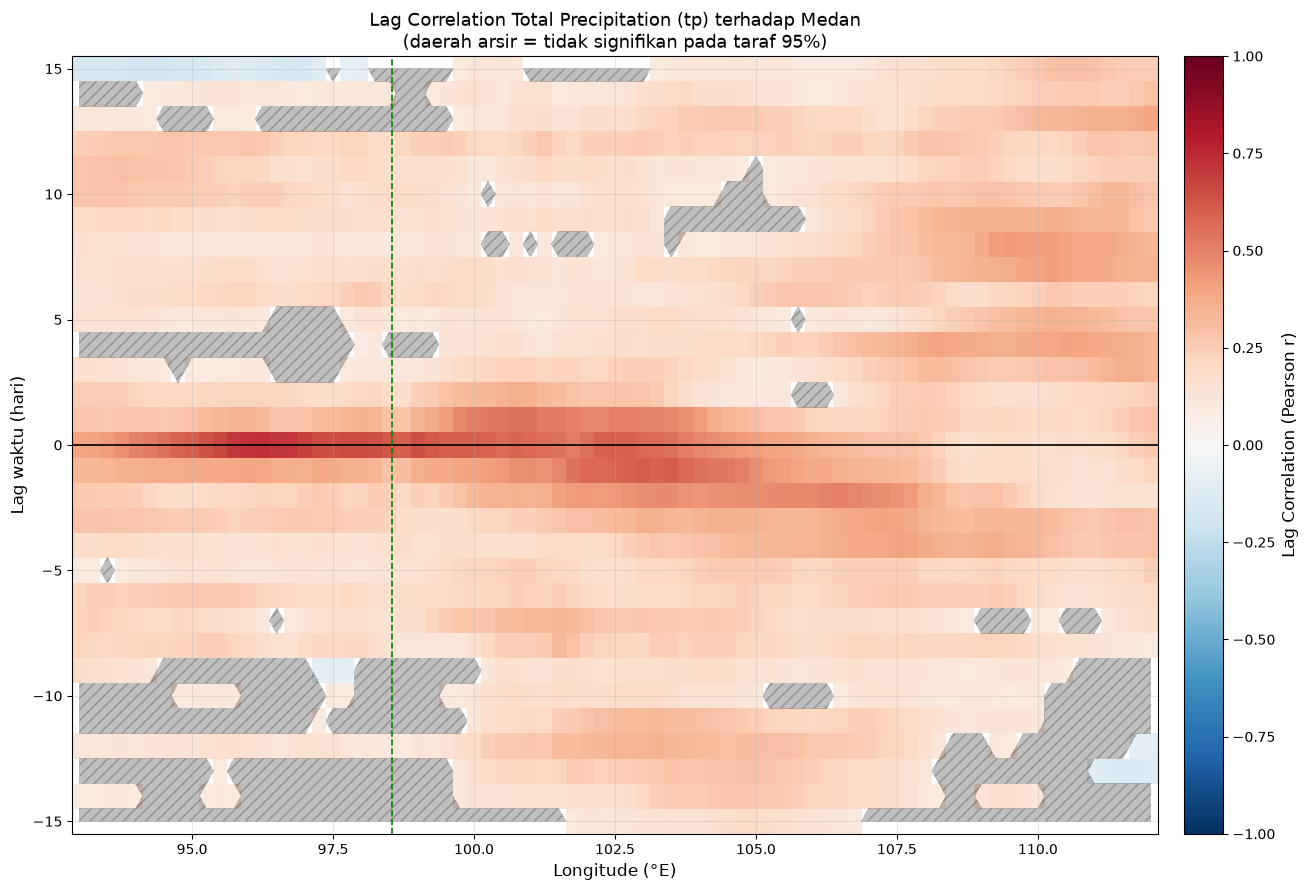

Korelasi |r| maksimum : +0.729 pada lag +0 hari, longitude 96.25°E
Rentang lag           : -15 s/d 15 hari
Jumlah time step      : 455 hari


In [22]:
# === Lag Correlation: tp vs longitude ===
# Referensi: deret waktu tp rata-rata pada kotak wilayah Kota Medan
tp_ref = (ds_copy['tp']
          .sel(latitude=slice(lat_max, lat_min),
               longitude=slice(lon_min, lon_max))
          .mean(dim=['latitude', 'longitude']))

lons = ds_copy.longitude.values
tp_lon = ds_copy['tp'].mean(dim='latitude')  # (valid_time, longitude), satuan mm
n_time = tp_lon.sizes['valid_time']

# --- Hapus siklus musiman (daily climatology) agar lag correlation tidak
# --- didominasi oleh siklus tahunan/semi-tahunan
date_index = pd.DatetimeIndex(pd.to_datetime(ds_copy.valid_time.values))
doy = date_index.dayofyear

ref = tp_ref.values.astype(float)
data = tp_lon.values.astype(float)

unique_doy = np.unique(doy)
ref_clim = np.array([ref[doy == d].mean() for d in unique_doy])
ref_deseas = ref - ref_clim[np.searchsorted(unique_doy, doy)]

data_clim = np.array([data[doy == d, :].mean(axis=0) for d in unique_doy])
data_deseas = data - data_clim[np.searchsorted(unique_doy, doy), :]

# --- Hitung lag correlation ---
# corr[lag, lon] = Pearson( ref(t), tp(lon)(t + lag) )
# lag > 0 : tp di longitude tsb berpuncak SETELAH Medan
# lag < 0 : tp di longitude tsb berpuncak SEBELUM Medan
lags = np.arange(-15, 16)  # rentang lag (hari)
corr = np.full((len(lags), len(lons)), np.nan)

for li, lag in enumerate(lags):
    if lag >= 0:
        a, b = (ref_deseas[:-lag] if lag else ref_deseas), data_deseas[lag:]
    else:
        a, b = ref_deseas[-lag:], data_deseas[:lag]
    # Pearson: cov(ref, tp_lon) / (std(ref) * std(tp_lon)) dihitung per kolom longitude
    a = a - a.mean()
    b = b - b.mean(axis=0, keepdims=True)
    std_a = np.sqrt((a ** 2).sum())
    std_b = np.sqrt((b ** 2).sum(axis=0))
    corr[li, :] = (b.T @ a) / (std_a * std_b)

# --- Uji signifikansi (t-test 2 sisi, 95%) dengan ukuran sampel efektif ---
alpha = 0.05
from scipy import stats
t_crit = stats.t.ppf(1 - alpha / 2, df=n_time - 2)
se = 1.0 / np.sqrt(n_time - 3)
not_significant = np.abs(corr) < t_crit * se

# --- Visualisasi ---
fig, ax = plt.subplots(figsize=(14, 9))

im = ax.pcolormesh(lons, lags, np.ma.masked_where(not_significant, corr),
                   cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.contourf(lons, lags, not_significant.astype(float), levels=[0.5, 1.5],
            hatches=['///'], colors='none', alpha=0.25)  # arsiran = tidak signifikan

ax.axhline(0, color='black', linewidth=1.2, linestyle='-')
ax.axvline((lon_min + lon_max) / 2, color='green', linewidth=1.2, linestyle='--')

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Lag Correlation (Pearson r)', fontsize=12)

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Lag waktu (hari)', fontsize=12)
ax.set_title(f'Lag Correlation Total Precipitation (tp) terhadap Medan\n'
             f'(daerah arsir = tidak signifikan pada taraf {int((1-alpha)*100)}%)',
             fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('D:/ERA5_REANALYSIS/Senyar_Cylone/Lag_Correlation', exist_ok=True)
plt.savefig('D:/ERA5_REANALYSIS/Senyar_Cylone/Lag_Correlation/LagCorr_tp_vs_longitude.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan singkat
abs_corr = np.abs(corr)
li_max, lo_max = np.unravel_index(np.nanargmax(abs_corr), corr.shape)
print(f'Korelasi |r| maksimum : {corr[li_max, lo_max]:+.3f} pada lag {lags[li_max]:+d} hari, '
      f'longitude {lons[lo_max]:.2f}°E')
print(f'Rentang lag           : {lags[0]} s/d {lags[-1]} hari')
print(f'Jumlah time step      : {n_time} hari')

## Analisis Space-Time Spectrum: Metode Wheeler–Kiladis

Analisis ini mengadaptasi pendekatan **Wheeler & Kiladis (1999)** untuk mengidentifikasi sistem gelombang tropis (mis. MJO, easterly waves) dalam bidang **wavenumber–frekuensi**.

- **Sumbu x** = zonal wavenumber $k$ (cycles/360°)
- **Sumbu y** = frekuensi $f$ (cycles/hari); sumbu kanan menunjukkan periode (hari)
- Warna = power spectrum ($\log_{10}$), dipecah menjadi komponen **eastward** ($k<0$, propagasi ke timur) dan **westward** ($k>0$, propagasi ke barat)

**Langkah komputasi:**
1. Rata-ratakan data terhadap latitude → deret 2D (waktu, longitude).
2. Hilangkan siklus musiman (fit harmonik tahunan & semi-tahunan).
3. Taper Hanning pada sumbu waktu & longitude.
4. Hitung 2D-FFT; power $P(k,f) = 4\,|X_2(k,f)|^2/(N_t N_l)^2$.
5. $k$ didefinisikan relatif terhadap lebar domain: $k = 360\,m/L$.

> ⚠️ **Catatan domain:** Data hanya selebar $L = 19°$ (93–112°E). Gelombang terpanjang yang bisa di-resolve adalah $\lambda = L$ ($k \approx 19$). Gelombang MJO global ($\lambda \approx 100$–150°) **tidak muat** dalam domain ini, sehingga $k$ di sini adalah wavenumber *relatif terhadap domain*, bukan wavenumber global. Pita intramusiman (20–90 hari) disorot dengan warna cyan.

In [ ]:
# === Wheeler–Kiladis Space-Time Spectrum ===
# Variabel yang dianalisis (ubah sesuai kebutuhan)
wk_var = 'tp'

def wheeler_kiladis(da, dt=1.0, remove_seasonal=True):
    """Space-time spectrum (Wheeler & Kiladis 1999) dari DataArray 2D (valid_time, longitude).
    k didefinisikan relatif terhadap lebar domain: k = 360*m/L (cycles/360deg)."""
    x = np.asarray(da.values, dtype=float)
    if x.ndim != 2:
        raise ValueError("Data harus 2D (valid_time, longitude); rata-ratakan latitude dulu.")
    x = np.nan_to_num(x, nan=0.0)
    n_t, n_l = x.shape
    L = float(np.ptp(da.longitude.values))

    # 1) Hilangkan siklus musiman (tahunan & semi-tahunan)
    if remove_seasonal:
        t = np.arange(n_t, dtype=float)
        Xs = np.column_stack([
            np.ones(n_t),
            np.cos(2*np.pi*t/365.25),  np.sin(2*np.pi*t/365.25),
            np.cos(2*np.pi*2*t/365.25), np.sin(2*np.pi*2*t/365.25),
        ])
        beta = np.linalg.lstsq(Xs, x, rcond=None)[0]
        x = x - Xs @ beta

    # 2) Taper Hanning (waktu & longitude)
    x = x * np.hanning(n_t)[:, None] * np.hanning(n_l)[None, :]

    # 3) 2D-FFT (lon, time)
    X2 = np.fft.fft2(x.T)
    fsgn = np.fft.fftfreq(n_t, d=dt)
    P = 4.0 * (np.abs(X2)**2) / (n_t*n_l)**2

    # 4) Wavenumber relatif terhadap lebar domain; pisahkan eastward (k<0) & westward (k>0)
    m  = np.arange(1, n_l//2 + 1)
    fi = np.where(fsgn > 0)[0]
    F  = fsgn[fi]
    K  = 360.0 * m / L
    Pw = P[np.ix_( m,  fi)]   # k > 0 -> propagasi ke barat
    Pe = P[np.ix_(-m,  fi)]   # k < 0 -> propagasi ke timur

    return dict(K=K, F=F, Pe=Pe, Pw=Pw, Ptot=Pe+Pw,
                ce= F[None,:]*360.0/K[:,None],   # kecepatan fase eastward (°/hari, +)
                cw=-F[None,:]*360.0/K[:,None],   # kecepatan fase westward (°/hari, -)
                L=L, n_t=n_t, n_l=n_l)

def plot_wk(res, var, f_range=(0.005, 0.20), title=None, save_path=None,
            f_lo_ax=0.005, f_hi_ax=0.20):
    """Gambar 4 panel: (a) total, (b) eastward, (c) westward, (d) arah kecepatan fase."""
    K, F = res['K'], res['F']
    mf = (F >= f_range[0]) & (F <= f_range[1])
    Ks, Fs = K, F[mf]
    # mask dulu (axis 1 = frekuensi), lalu transpose -> (n_F, n_K) untuk pcolormesh
    Ptot = res['Ptot'][:, mf].T
    Pe   = res['Pe'][:,   mf].T
    Pw   = res['Pw'][:,   mf].T
    ce   = res['ce'][:,   mf].T
    cw   = res['cw'][:,   mf].T
    c_dom = np.where(Pe >= Pw, ce, cw)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))
    logpow = lambda A: np.log10(A + 1e-30)
    xticks = [20, 50, 100, 200, 500]

    def _style(ax, ylabel=True):
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(Ks.min()*0.85, Ks.max()*1.15)
        ax.set_ylim(f_lo_ax, f_hi_ax)
        ax.set_xticks(xticks); ax.set_xticklabels([f'{t:g}' for t in xticks])
        ax.set_xlabel('Zonal wavenumber  k  (cycles/360°)')
        if ylabel: ax.set_ylabel('Frekuensi f (cycles/hari)')
        ax.grid(True, which='both', alpha=0.25)
        ax2 = ax.twinx()
        ax2.set_yscale('log'); ax2.set_ylim(ax.get_ylim())
        pt = [5, 10, 20, 50, 100, 200]
        pt = [p for p in pt if 1/p >= ax.get_ylim()[0] and 1/p <= ax.get_ylim()[1]]
        ax2.set_yticks([1/p for p in pt]); ax2.set_yticklabels([f'{p}d' for p in pt])
        ax2.set_ylabel('Periode (hari)')
        # sorot pita intramusiman 20-90 hari
        ax.axhspan(1/90, 1/20, color='cyan', alpha=0.10, zorder=0)

    # (a) Power spectrum total + tandai puncak intramusiman
    ax = axes[0, 0]
    im = ax.pcolormesh(Ks, Fs, logpow(Ptot), cmap='magma', shading='auto')
    ax.contour(Ks, Fs, logpow(Ptot), levels=8, colors='w', alpha=0.35, linewidths=0.7)
    mb = (Fs >= 1/90) & (Fs <= 1/20)
    P_is = np.where(mb[:, None], Ptot, np.nan)
    ii, jj = np.unravel_index(np.nanargmax(P_is), P_is.shape)
    ax.plot(Ks[jj], Fs[ii], 'w*', ms=15, mec='k', mew=0.8, zorder=5)
    arah = 'TIMUR' if Pe[ii, jj] >= Pw[ii, jj] else 'BARAT'
    ax.annotate(f'Puncak intramusiman:\nk = {Ks[jj]:.0f} (λ = {360/Ks[jj]:.1f}°)\n'
                f'f = {Fs[ii]:.3f}/hari (T = {1/Fs[ii]:.0f} d)\npropagasi ke {arah}',
                xy=(Ks[jj], Fs[ii]), xytext=(Ks[jj]*1.6, Fs[ii]*2.2),
                color='white', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='white', lw=1.2))
    cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('log10 Power')
    _style(ax); ax.set_title('(a) Power spectrum total')

    # (b) Eastward
    ax = axes[0, 1]
    im = ax.pcolormesh(Ks, Fs, logpow(Pe), cmap='BuPu', shading='auto')
    cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('log10 Power (eastward)')
    _style(ax); ax.set_title('(b) Eastward (k < 0, propagasi ke timur)')

    # (c) Westward
    ax = axes[1, 0]
    im = ax.pcolormesh(Ks, Fs, logpow(Pw), cmap='OrRd', shading='auto')
    cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('log10 Power (westward)')
    _style(ax, ylabel=False); ax.set_title('(c) Westward (k > 0, propagasi ke barat)')

    # (d) Arah kecepatan fase
    ax = axes[1, 1]
    im = ax.pcolormesh(Ks, Fs, np.sign(c_dom), cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
    ax.contour(Ks, Fs, np.log10(np.abs(c_dom)+1e-12), levels=6, colors='k', alpha=0.5, linewidths=0.8)
    cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('arah: merah = timur, biru = barat')
    _style(ax, ylabel=False); ax.set_title('(d) Kecepatan fase  c = 360·f/k  (kontur = |c|, °/hari)')

    fig.suptitle(title or var, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig

# --- Siapkan data: rata-rata terhadap latitude (2D: waktu x longitude) ---
# Gunakan ds_copy agar satuan sudah dikonversi (tp dalam mm)
wk_da = ds_copy[wk_var].mean(dim='latitude')
res = wheeler_kiladis(wk_da)

title = (f'Wheeler–Kiladis Space-Time Spectrum — {var_name[wk_var]}\n'
         f'ERA5 2025-01-01 s.d. 2026-03-31, 93–112°E (L = {res["L"]:.0f}°, rata-rata latitude)')
plot_wk(res, wk_var, title=title,
        save_path=f'D:/ERA5_REANALYSIS/Senyar_Cylone/WK_Analysis/WK_{wk_var}_space_time.png')

# --- Ringkasan kuantitatif ---
F, K = res['F'], res['K']
mb = (F >= 1/90) & (F <= 1/20)   # pita intramusiman 20-90 hari
ew_ratio = res['Pe'][:, mb].sum() / max(res['Pw'][:, mb].sum(), 1e-30)
print(f'Lebar domain L        : {res["L"]:.1f}°  (n_t = {res["n_t"]}, n_lon = {res["n_l"]})')
print(f'Rentang k             : {K[0]:.1f} s/d {K[-1]:.1f} cycles/360°')
print(f'Gelombang terpanjang  : λ = L = {res["L"]:.0f}° (k ≈ {K[0]:.0f})')
print(f'Rasio power E/W (20-90d): {ew_ratio:.2f}  '
      f'({"DOMINAN TIMUR" if ew_ratio > 1 else "DOMINAN BARAT"})')

In [ ]:
# Create Hovmoller diagrams for all variables in the dataset
coordinate_vars = ['latitude', 'longitude']
for coord in coordinate_vars:
    dimension = 'latitude' if coord == 'longitude' else 'longitude'
    for var in var_names:
        # Create Hovmoller diagram with longitude on x-axis and time on y-axis for each variable
        fig, ax = plt.subplots(figsize=(12, 8))

        # Filter the dataset for the desired time range (optional)
        ds_filtered = ds_copy
        #ds_filtered = ds_copy.sel(valid_time=slice('2025-11-01', '2025-12-31'))

        # Plot the Hovmoller diagram
        im = ax.pcolormesh(ds_filtered[coord], ds_filtered.valid_time, ds_filtered[var].mean(dim=dimension), cmap='viridis', shading='auto')

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        # Get the units from the actual variable in the dataset
        var_units = ds_copy[var].attrs.get('units', '')  # Use .attrs.get to safely get units if they exist
        cbar.set_label(f'{var_name[var]} ({var_units})')

        # Set labels and title
        ax.set_xlabel(coord.capitalize())
        ax.set_ylabel('Time')
        ax.set_title(f'Hovmoller Diagram of {var_name[var]}')

        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45)

        # Show the plot
        plt.tight_layout()
        plt.savefig(f'D:/ERA5_REANALYSIS/Senyar_Cylone/Hovmuller_plot/Hovmoller_{var_name[var]}_{coord}.png')  # Save the figure as a PNG file

## Analisis Fourier Transform: Frekuensi vs Longitude/Latitude (Semua Variabel)
Analisis ini menggunakan Transformasi Fourier untuk mengidentifikasi dominansi frekuensi dari variabel meteorologi yang ada pada setiap bujur (longitude) ataupun lintang (latitude). Plot 2D histogram menampilkan sumbu x = longitude/latitude, sumbu y = frekuensi, dan warna menunjukkan kekuatan sinyal (power).

In [ ]:
# Analisis Fourier Transform: Frekuensi vs Longitude untuk variabel tp
# Menggunakan ds_copy yang sudah dikonversi satuannya (tp dalam mm)
for coord in coordinate_vars:
    dimension = 'latitude' if coord == 'longitude' else 'longitude'
    for var in var_names:
        # Ambil data variabel, rata-rata sepanjang latitude untuk setiap longitude
        var_lon_time = ds_copy[var].mean(dim=dimension)  # dimensi: (valid_time, longitude)

        # Ambil informasi dimensi
        lons = var_lon_time[coord].values
        times = var_lon_time.valid_time.values
        n_time = len(times)

        # Hitung selang waktu harian (asumsi data harian)
        dt = 1.0  # hari

        # Hitung FFT untuk setiap longitude
        frequencies = np.fft.rfftfreq(n_time, d=dt)  # frekuensi dalam cycles/hari
        n_freq = len(frequencies)

        # Inisialisasi array power spectrum 2D (longitude x frequency)
        power_spectrum = np.zeros((n_freq, len(lons)))

        # Hitung power spectrum untuk setiap longitude/latitude
        for i, lon in enumerate(lons):
            var_series = var_lon_time.sel(**{coord: lon}).values
            # Hilangkan mean (detrending sederhana)
            var_series = var_series - np.nanmean(var_series)
            # Ganti NaN dengan 0 jika ada
            var_series = np.nan_to_num(var_series, nan=0.0)
            # Hitung FFT
            fft_vals = np.fft.rfft(var_series)
            # Power spectrum = |FFT|^2
            power_spectrum[:, i] = np.abs(fft_vals) ** 2

        # Konversi ke dB untuk visualisasi yang lebih baik
        power_spectrum_db = 10 * np.log10(power_spectrum + 1e-10)  # tambah epsilon untuk hindari log(0)
        
        # === Visualisasi 2D Histogram (Pcolormesh) ===
        fig, ax = plt.subplots(figsize=(14, 8))

        # Plot 2D dengan longitude di sumbu x dan frekuensi di sumbu y
        im = ax.pcolormesh(lons, frequencies, power_spectrum_db, cmap='viridis', shading='auto')

        # Tambahkan colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Power Spectrum (dB)', fontsize=12)

        # Set label dan judul
        ax.set_xlabel(coord.capitalize(), fontsize=12)
        ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
        ax.set_title(f'Fourier Transform: Power Spectrum of {var_name[var]}\nFrequency vs {coord.capitalize()}', fontsize=14)

        # Tambahkan garis periode dominan sebagai referensi
        # Periode = 1/frekuensi
        period_ticks = [1, 2, 5, 10, 20, 50, 100]  # hari
        period_labels = ['1d', '2d', '5d', '10d', '20d', '50d', '100d']
        valid_periods = [p for p in period_ticks if 1.0/p >= frequencies[1] and 1.0/p <= frequencies[-1]]
        valid_labels = [period_labels[i] for i, p in enumerate(period_ticks) if p in valid_periods]

        if valid_periods:
            valid_freqs = [1.0/p for p in valid_periods]
            ax2 = ax.twinx()
            ax2.set_ylim(ax.get_ylim())
            ax2.set_yticks(valid_freqs)
            ax2.set_yticklabels(valid_labels, fontsize=10)
            ax2.set_ylabel('Period (days)', fontsize=12)

        # Tampilkan plot
        plt.tight_layout()
        plt.savefig(f'D:/ERA5_REANALYSIS/Senyar_Cylone/Fourier_Analysis/FFT_{var_name[var]}_Frequency_vs_{coord.capitalize()}.png', dpi=150, bbox_inches='tight')

        print(f"Dimensi data {var}: {var_lon_time.dims}")
        print(f"Jumlah {coord}: {len(lons)}")
        print(f"Jumlah waktu: {n_time}")
        print(f"Jumlah frekuensi: {n_freq}")
        print(f"Rentang frekuensi: {frequencies[1]:.4f} - {frequencies[-1]:.4f} cycles/day")
        print(f"Rentang {coord.capitalize()}: {lons.min():.2f} - {lons.max():.2f}")